<a href="https://colab.research.google.com/github/PSriChandana/Data-Imputation/blob/main/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Binary Classification using Gradient Descent


```
Binary classification is a machine learning task that sorts data into one of two groups, such as yes or no, spam
or not spam, or healthy or sick. It uses input features
from past data to train an algorithm to predict the
correct label for new information.```




In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
training_data=pd.read_csv('engineTest.csv')
test_data=pd.read_csv('engineTestCheck.csv')

In [5]:
print(training_data.columns)
print(test_data.columns)

Index(['Test', 'X1', 'X2', 'X3', 'X4', 'X5', 'Result'], dtype='object')
Index(['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5'], dtype='object')


In [10]:
print((training_data['Result']).value_counts())

Result
Fail    51
Pass    49
Name: count, dtype: int64


In [15]:
#Treating the problem as a 2D problem. We are gonna use X1 and X2 for the optimization to represent on the graph
train_data1=pd.DataFrame({'X0':np.repeat(1,len(training_data))})
train_data1[['X1','X2','Result']]=training_data[['X1','X2','Result']]
print(train_data1)

    X0     X1     X2 Result
0    1  57.00  65.00   Pass
1    1  57.00  64.94   Pass
2    1  22.00  13.00   Fail
3    1  26.87  14.19   Fail
4    1  57.50  63.95   Pass
..  ..    ...    ...    ...
95   1  57.00  65.50   Pass
96   1  55.11  65.98   Pass
97   1  16.00  13.00   Fail
98   1  21.17  11.15   Fail
99   1  59.41  66.35   Pass

[100 rows x 4 columns]


In [18]:
n_k=np.repeat(10,3)
#n_kprev is created to enable updates n_k in the loop
n_kprev=np.repeat(0,3)
#step length
clearn=0.1
#create a boolean variable to verify if all samples meet the conditions
updateCounter=True
#classification criteria
maxIteration=2000
iteration=1


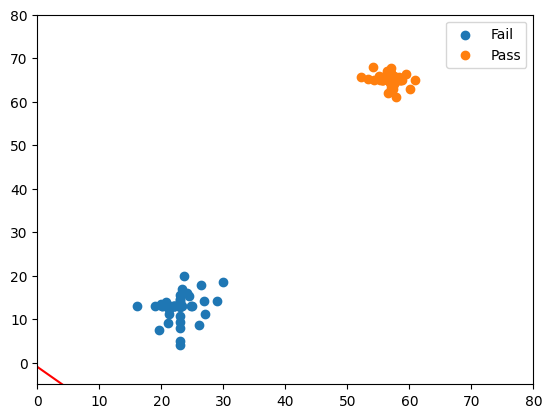

In [58]:
#Group training_data according to the Result
grouped_data=train_data1.groupby(by='Result')

for key in grouped_data.groups.keys():
  data=grouped_data.get_group(key)
  x=data['X1']
  y=data['X2']
  plt.scatter(x,y,label=key)
  plt.xlim(0,80)
  plt.ylim(-5,80)
  plt.legend()

  slope=-1*n_k[1]/n_k[2]
intercept=-1*n_k[0]/n_k[2]
X = np.arange(80)
Y=slope*X+intercept
plt.plot(X,Y,c='red')
plt.show()



PLOTTING: 1 0


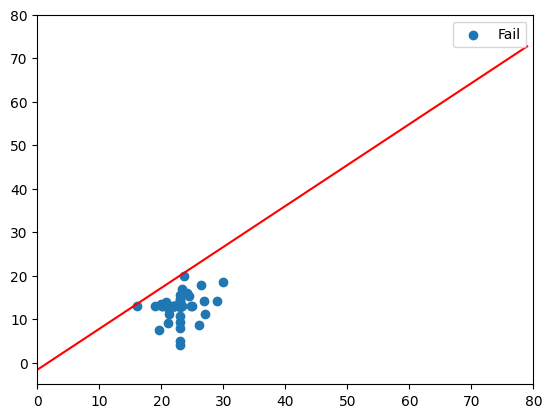

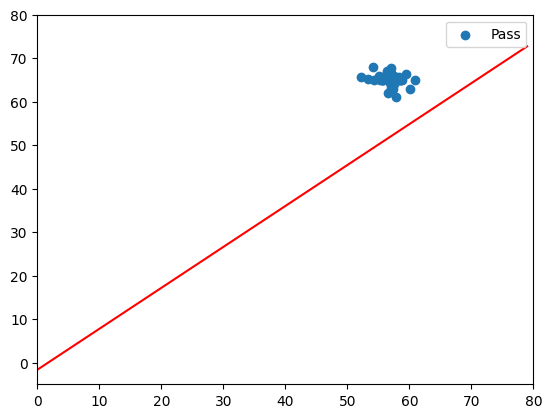

PLOTTING: 1 15


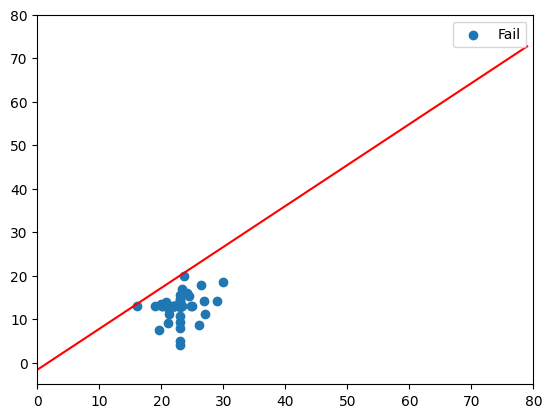

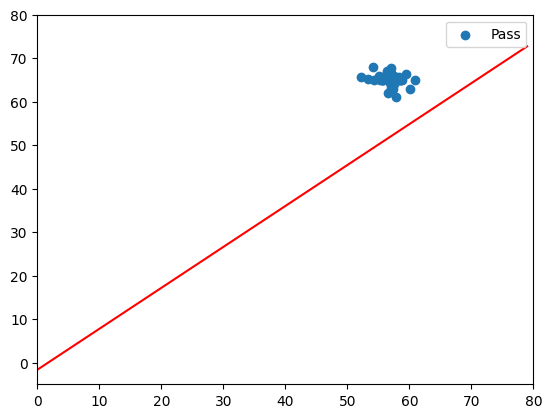

PLOTTING: 1 30


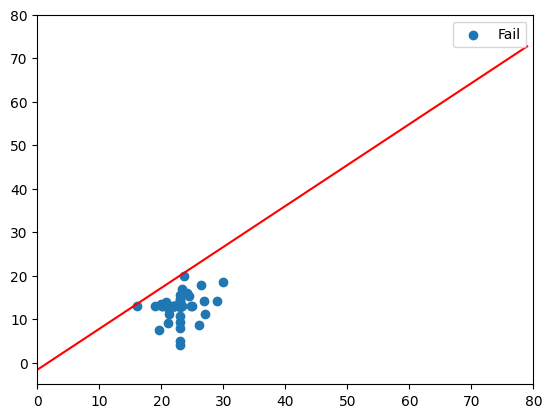

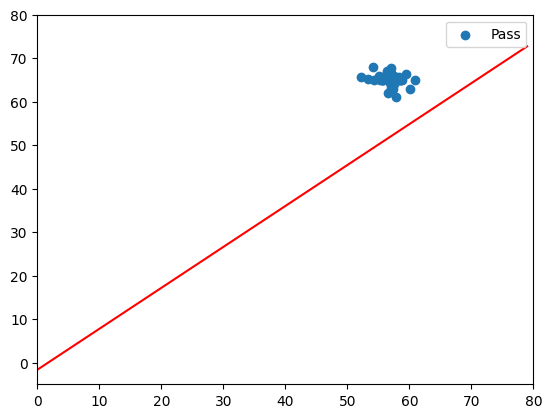

PLOTTING: 1 45


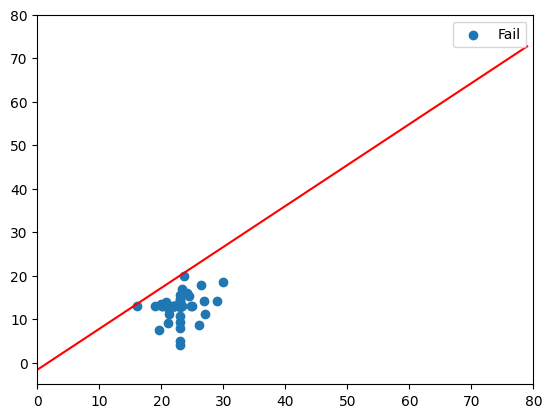

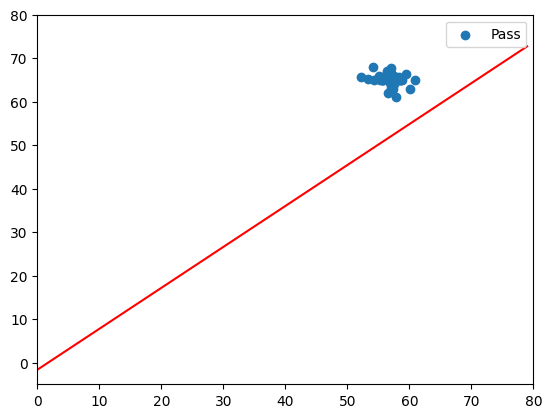

PLOTTING: 1 60


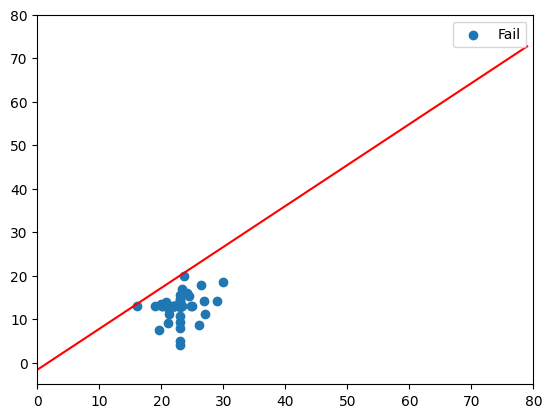

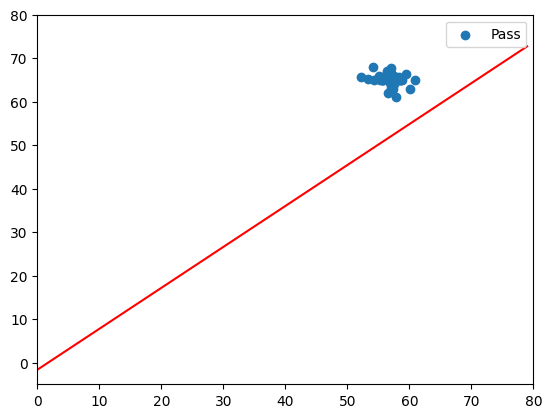

PLOTTING: 1 75


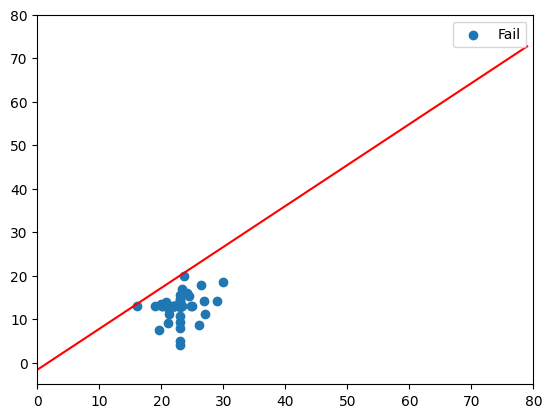

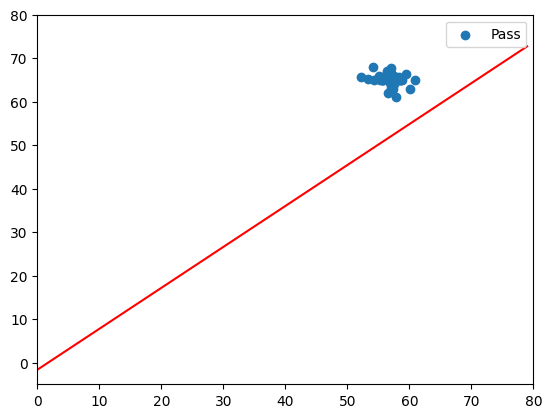

PLOTTING: 1 90


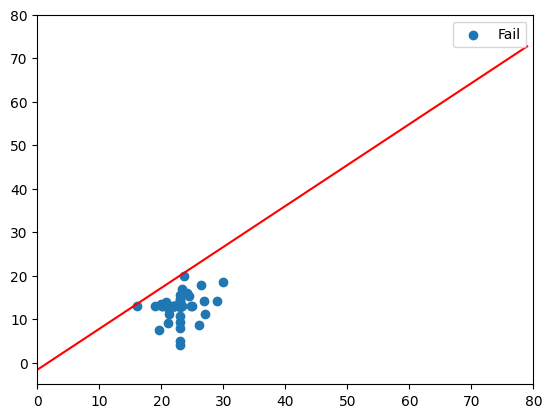

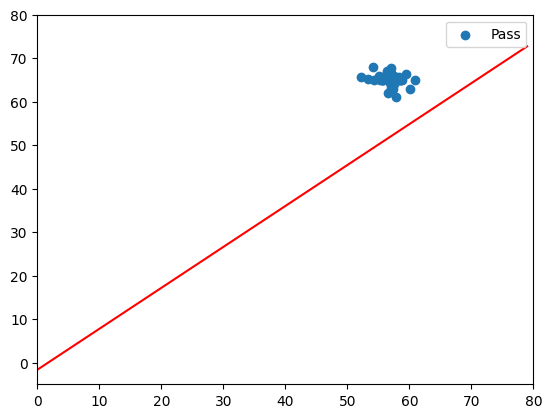

In [64]:
#ALgo for Gradient Descent
updateCounter=True
iteration=1
while updateCounter and iteration<maxIteration:
  updateCounter=False#need to update the counter
  for i in range(len(train_data1)):
    n_kprev=n_k
    pred=np.array(train_data1.iloc[i,0:3]).dot(n_k)
    #iloc=selects rows accordign to location and the columns it chooses are including 0 excluding
    #dot()is for dot product
    #print(pred)
    if(train_data1.Result[i]=="Pass" and pred<0):
      n_k=n_kprev+clearn*((np.array(train_data1.iloc[i,0:3])).T)
      updateCounter=True
    elif(train_data1.Result[i]=="Fail" and pred>0):
      n_k=n_kprev-clearn*((np.array(train_data1.iloc[i,0:3])).T)
      updateCounter=True
      #to plot graph and understand visually
    if(i%15 ==0 and iteration<=2):
      print("PLOTTING:", iteration, i)
      grouped_data = train_data1.groupby(by="Result")
      for key in grouped_data.groups.keys():
        data = grouped_data.get_group(key)
        x = data["X1"]
        y = data["X2"]
        plt.scatter(x, y, label=key)
        plt.xlim(0,80)
        plt.ylim(-5,80)
        plt.legend()
        slope=-1*n_k[1]/n_k[2]
        intercept=-1*n_k[0]/n_k[2]
        X = np.arange(80)
        Y=slope*X+intercept
        plt.plot(X,Y,c='red')
        plt.show()
  iteration=iteration+1
